# AAI 6610 Assignment 6: Deep Q-Learning

**Environment: MountainCar-v1** (per Canvas assignment instructions)

> **Note:** The original template referenced CartPole-v1, but the assignment on Canvas specifies the Mountain Car environment. I have updated he environment initialization in the setup cell to correlate with `MountainCar-v1` accordingly. This is the only modification made to the "DO NOT CHANGE" sections — all other template code remains untouched.

**Mountain Car Overview:**
- **Goal:** Drive an underpowered car up a steep hill by building momentum (swinging back and forth)
- **State Space:** 2 continuous values — position [-1.2, 0.6] and velocity [-0.07, 0.07]
- **Action Space:** 3 discrete actions — push left (0), no push (1), push right (2)
- **Reward:** -1 per timestep until the car reaches the flag at position 0.5 (or episode truncates at 200 steps)
- **Challenge:** Sparse reward — the agent gets -1 every step, so total reward ranges from -200 (never reached goal) to ~ -100 (reached goal quickly)


### Initializing the Environment
Run the following code blocks to install and import the relevant software as well as setting up the CartPole environment. While you do not need to modify any code in this section, it is important to ensure you run each block as later parts of the assignment rely on you having done this.

In [13]:
#### DO NOT CHANGE ####

# install prerequiste libraries
!pip install gymnasium numpy matplotlib pandas pygame jinja2 torch


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [26]:
#### DO NOT CHANGE (except environment: updated to MountainCar-v1 per Canvas instructions) ####

# This will ensure proper display of plots in Jupyter notebooks
%matplotlib inline

# load the required libraries
import gymnasium as gym
import matplotlib.pyplot as plt
import pandas as pd
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import clear_output

os.environ["SDL_VIDEODRIVER"] = "dummy"

# set seed for repeatability
random.seed(20)

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# initialize the environment
env = gym.make("MountainCar-v0", render_mode="rgb_array")

# Convenience method for displaying what your environment is doing
def display_env(env):
    # make environment embeddable in a Jupyter Notebook
    clear_output(wait=True)
    plt.imshow( env.render() )
    plt.show()
    
    
print("-" * 50)
print("MountainCar-v0 Environment initialized successfully!")

Using device: cpu
--------------------------------------------------
MountainCar-v0 Environment initialized successfully!


### Defining your Model
In this section you will make decisions about your Deep Q-Learning Network architecture and hyperparameters.

#### Define your DQ Architecture
Complete the following code block to define your Deep Q-Learning Network. This is the model that you will train to predict Q-values. Follow the instructions to select your model structure (the number and size of your layers) and forward pass (how data moves through your model and what activation functions are used).

In [38]:
'''
The goal of this section is to define hte DQN architecture for the Mountain Car environment and setup the forward pass. 

- The DQN architecture consists of 2 hidden layers (input layer and 2 hidden layer that requires ReLU activation) and an output layer (does not require activation since we need the raw Q-Values)
- The forward pass is how the data flows through the network to produce the output Q- values for each action.

- setup input and output dimensions for Mountain Car. We need wider dimensions for the hidden layers than the 12,8 used for Frozen Lake since
    Mountain Car has a continous state space.

References: https://docs.pytorch.org/tutorials/intermediate/reinforcement_q_learning.html

'''


class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        
        #### DEFINE YOUR NEURAL STRUCTURE HERE ####
        
        self.fc1 = nn.Linear(input_dim, 128) # 1st hidden layer wit 128 neurons 
        self.fc2 = nn.Linear(128, 128) # second hidden later 
        self.fc3 = nn.Linear(128, output_dim) # output layer with 3 neurons of left, none, right

    def forward(self, x):

        #### DEFINE YOUR FORWARD PASS HERE ####
        
        # using ReLU actication for hidden layers , and not acvtivation for output layers since we are trying to get the raw Q values
        # also to help with vanishing gradient problem
        x = torch.relu(self.fc1(x)) # hidden layer 1 + RELU activation 
        x = torch.relu(self.fc2(x)) # hidden layer 2 + RELU activation
        x = self.fc3(x) # output later with no actication 
        
        # return the output of the network 
        return x

# print the model architecture compiled 
print("DQN Architecture compiled successfully!")
print("-" * 50)

# test your DQN architecture
dqn = DQN(input_dim=2, output_dim=3)
print(dqn)

DQN Architecture compiled successfully!
--------------------------------------------------
DQN(
  (fc1): Linear(in_features=2, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=3, bias=True)
)


#### Set your Hyperparameters
Complete the following code block to define your hyperparameters. Hyperparameters can have a large impact on how quickly and how effectively your model can train so you may want to experiment with some different values.

In [16]:
#### SET YOUR HYPERPARAMETERS HERE ####
# Mountain Car is challenging due to sparse rewards (-1 every step)

gamma = 0.99                    # discount factorr for future rewards
epsilon = 1.0                   # starting value of epsilon for exploration 
epsilon_decay = 0.995           # multiply epsilon by each episode 
epsilon_min = 0.01              # minimum value for epsilon for exploration
batch_size = 128                # number of transitions of sample replay 
target_update_freq = 10         # update traget network every 10 episodes 
learning_rate = 0.001           # step size for optimzier 

print("-" * 50)
print("Hyperparameters set successfully!")

--------------------------------------------------
Hyperparameters set successfully!


#### Initialize your Network
Run the following code block to ensure you model is properly initialized. Ensure you rerun this block after making any changes to `DQN`.

In [17]:
#### DO NOT CHANGE ####

# Get the input and output dimensions
input_dim = env.observation_space.shape[0]
output_dim = env.action_space.n
 
# Initialize the DQN model
model = DQN(input_dim, output_dim)
 
# Initialize the target network
target_model = DQN(input_dim, output_dim)
target_model.load_state_dict(model.state_dict())

# Replay buffer holds your previous results
replay_buffer = []

#### Choose your Optimizer and Loss Function
Complete the following code block to define your optimizer and loss function. This will affect not only how your model updates its weights but also how it evaluates its success.

In [18]:
#### INITIALIZE THE OPTIMIZER AND LOSS FUNCTION ####


# Adam optimizer good for DQN because it allows the learning ratet to adapt during training
optimizer = optim.Adam(model.parameters(), lr=learning_rate)   # Adaptive learning rate, most common for DQN  

criterion = nn.SmoothL1Loss()       # Huber Loss - less sensitive to outliers



#### Explain your Desicions
In the markdown block below, describe in your own words why you made the above model choices. Explain your thinking clearly and provide justifications where appropriate.

#### ENTER YOUR ANSWER HERE ####


When developing the architecture of this network there were few things to take into consideration like the gymnasium dimensions for the Mountaincar in comparison to what was used for the Cartpole architecture. A wider dimension allows for the model to have more space to work with due to mountain car continuous state space. When using MountainCar in DQN (Deep Q Networks) it faces a elevated level of difficulty because of its spare reward structure. If the model received a positive reinforcement reward at every correct path the model will simply get stuck in a loop and never explore newer paths to the goal. So, as a result the agent needs to learn momentum building to overcome steep or flat obstacles, while having smooth and adaptive navigation within the environment. 

It utilizes ReLU activation over sigmoid/tanh because ReLU addresses the vanishing gradients better when dealing with hidden layers. ReLU also provides faster compute and is needed when working with the large environment. –Sigmoid is not being used because outputs it values between 0 and 1, which creates two problems. First, it contributes to the vanishing gradient issue by saturating input values as gradients approach zero, this increases training difficulty within the deep layers (Geron, 2019). Second, it does not align with Mountain Car’s Q-values because it’s attempting to compress all outputs to a positive range when the Q-values need to represent negative rewards. Tanh was not an optimal choice because we do not need the output to be centered near or at zero. Although it slightly improves on sigmoid by outputting negative and positive values between -1 and 1 it still has risks of saturation and vanishing gradients. The output layer doesn’t require activation because we need the raw Q-values it predicted. These values range well below -1, where in Mountain Car is goes as low as (-200) to positive state (0) is the goal. Overall, ReLU avoids both issues of vanishing gradients and saturation, by providing simple non-linearity while maintaining strong gradients during backpropagation allowing for faster compute.


The specific hyperparameters were chosen to help influence convergence and mitigate from falling into an infinite loop. The gamma parameters allow the algorithm to prioritize the long-term success and its future rewards. The agent is trying to reach the positive signal that happens many steps later and if gamma were set closer to 0 then it would make the algorithm short-sighted and prioritized immediate gains. Since gamma is set to 0.99 it helps the algorithm handle uncertainty on future rewards, and discounts that uncertainty to learn and enhance its decision making to reach the goal state. Epsilon (1.0) and epsilon decays (0.995) allows the model to explore newer path states at a slow and controlled speed to allow the algorithm to explore as many positive signals as possible to ultimately discover the goal. Epsilon min is set to 0.01 to ensure a small level of random exploration. Even with training progressing it allows the agent to progress and not become greedy or stuck in a suboptimal policy, unable to discover new paths to the goal.

To help the algorithm train and find its optimal path in a timely manner, we use a batch size of 128. It takes a handful of samples in one iteration and then provides updates to the model on whether goal was found within that training batch, if not it continues with next batch of 128 until convergence out of all the episodes. Rather than updating from a single experience, it takes the average of all gradients across the 128 random experiences from the replay buffer. This randomness helps smooth out any noise during updates and helps push forward to convergence. The learning rate of 0.001 was chosen as its mainly the default step size for the optimizer and allows for controlled movement, and meaningful progressions (Kingma & Ba 2015). If the learning rate is too high or too low, it can either overshoot optimal values or result in slow training.

The target update frequency as set to 10 to allow the model to have a stable set of Q-values to learn against without having to update at every single step. Just a consistent benchmark before the targets refresh.

The reason I chose Adam optimizer because it’s an advance optimizer the combines RMSprop and Momentum optimizers to get the best of both worlds. Combining memory of continuous trend, movement and pattern, with adaptive adjustments in learning rate, and biases to allow for the ultimately flexibility across the 128,128 dimensions. 

Huber loss was chosen over Mean squared error loss because it hybrid loss function between Mean Squared Error and Mean Absolute Error. MSE handles the small errors while MAE handles the large errors and outliers and acknowledges the error but doesn’t overwhelm the Mountaincar trajectory by overreacting. Q-values estimates are normally inaccurate producing large errors. Using MSE alone against these errors, it would attempt to square them and create overly large gradients which create an imbalance in the network. Huber loss caps the influence of these outliers and provides stability and precision keeping its sensitivity a low controlled level to ensure that those large uncertain guesses do not break the neural network ultimately risking its opportunity to learn. It’s more accurate than Mean Square Error.

As a result of all these choices, it’s able to address Mountain Car’s challenge of sparse rewards. The agent must learn entirely on negative feedback and delayed success as it receives  -1 every step with no positive signal until the goal is reached. The hyperparameters help balance exploration versus exploitation tradeoff by ensuring the agent understands the goal is distant but has enough randomness to ensure forward progression. The 128 neurons provide capacity for continuous movement and space for optimal actions. While Adam and Huber loss handle the stabilization of the network against noise. Together, the algorithms decisions for the network help guide it to converge and to help solve Mountain Car.



References:

Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization. Proceedings of the 3rd International Conference on Learning Representations (ICLR 2015). https://arxiv.org/abs/1412.6980
PyTorch. (n.d.). Reinforcement learning (DQN) tutorial. PyTorch Tutorials. https://docs.pytorch.org/tutorials/intermediate/reinforcement_q_learning.html
PyTorch. (n.d.). SmoothL1Loss. PyTorch Documentation. https://pytorch.org/docs/stable/generated/torch.nn.SmoothL1Loss.html



### Define your Training Loop
Complete the following code block to implement the training step of your DQN. The block contains template code to make this process, as well as training the model itself, easier. Feel free to import any additional librarys you deem relevant.

In [30]:

def train_dqn(num_episodes=1000, visualize_env=False):
    # This will allow us to modify global variables
    global epsilon
    global replay_buffer

    # Used to store total reward acheived per training episode
    # Gives you an idea of how well your training went over time
    total_reward_by_episode = []

    # Training loop
    for episode in range(num_episodes):
        state, info = env.reset()
        state = torch.Tensor(state).unsqueeze(0)
        done = False
        total_reward = 0
    
        while not done:
            # Select an action using the epsilon-greedy policy
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                q_values = model(state)
                action = torch.argmax(q_values).item()
    
            # Take the action in the environment
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated  # Episode ends on either condition
            
            # verify if the car actually reaches the flag or not 
            if terminated:
                print(f"Episode {episode} reached the goal!")
                
            next_state = torch.Tensor(next_state).unsqueeze(0)

            # === Extra bonus step: Reward Shaping (helps Mountain Car converge) ===
            
            '''
            Found in the research this could help with the sparse reward problem found in Mountain car.
            
            checking to see if next_state got me higher up the hill or make me go faster in progression to the goal (which is the flag)
            found mountain car documentation to understand the velocity and position of the car and how to use it to shape the reward
            
            This will help the agent learn faster.
            
            https://gymnasium.farama.org/environments/classic_control/mountain_car/
            
            After further research I found that the position of the car ranges from -1.2 to 0.6 and the velocity ranges from -0.07 to 0.07.
            Also found that scaling the reward shape between 10 and 50 is a good sweet spot for learning and makes it large enough to over come negative time penalty of -1 per step, but not too large 
                so it wont cause instability.             
            '''
            
            position = next_state[0][0].item() # ranges from -1.2 to 0.6 
            velocity = abs(next_state[0][-1].item())    # the speed of the car, direction doesnt matter. We get the absolute value since reward momentum is in either direction. (-0.7 to 0.7)
            
            # shaping th reward for better learning signal, computer learns better off positive rewards. Hence the 1.2. 
            # 5.0 is a hyperparamter to tell the model how important height is versus speed and or time
            shaped_reward = reward + (position + 1.2) * 5.0 + (velocity * 50.0)
            
    
            # Store the experience in the replay buffer
            replay_buffer.append((state, action, shaped_reward, next_state, done))
            # Add this to limit buffer size:
            max_buffer_size = 10000
            if len(replay_buffer) > max_buffer_size:
                replay_buffer.pop(0)  # Remove oldest experience
                
            # Sample a batch of experiences from the replay buffer
            if len(replay_buffer) >= batch_size:
                batch = random.sample(replay_buffer, batch_size)
                states, actions, rewards, next_states, dones = zip(*batch)
    
                states = torch.cat(states)
                actions = torch.tensor(actions).unsqueeze(1)
                rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1)
                next_states = torch.cat(next_states)
                dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1)


                #### ADD CODE TO PERFORM A SINGLE TRAINING STEP ###                
                '''
                
                Utilize module 6 reading of Reinforcement Learning and Pytorch Reinforcement learning documentation to help with implmenting the DQN training step 
                
                https://docs.pytorch.org/tutorials/intermediate/reinforcement_q_learning.html
                
                
                Chapter 18, “Reinforcement Learning” (pp. 683-732) in Hands-On Machine Learning (Géron, 2022).

                Reference:

                Géron, A. (2022). Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow: Concepts, tools, and techniques to build intelligent systems (3rd Ed.). O'Reilly Media, Inc.
                '''
                
                # torch.no_grad() is used to prevent PyTorch from calculating gradients during the target Q-value computation, which is important for stability in DQN training.
                with torch.no_grad():
                    # compute target Q values using target network
                    next_Q_values = target_model(next_states) # get the Q values for the next states using the target network
                    max_next_Q_values = next_Q_values.max(dim=1, keepdim=True)[0]   # get the max Q value for each next state
                
                    # computer the target Q values using the Bellman equation
                    target_Q_values = (rewards + (1 - dones) * gamma * max_next_Q_values)
                    
                
                # get the predicted Q values for the actions we took using the main model
                predicted_Q_values = model(states).gather(1, actions)
                
                # computer Huber loss between the predicted and target Q values 
                loss = criterion(predicted_Q_values, target_Q_values)
                
                # optimize the model weights
                optimizer.zero_grad() # clear old gradients 
                loss.backward() # use backpropgation to compute new gradients
                
                # to prevent exploding gradients, we clip the graidents to a max value 
                torch.nn.utils.clip_grad_value_(model.parameters(), 100)
                
                # update the model weights 
                optimizer.step()


                
    
            state = next_state
            total_reward += shaped_reward

            # Visualize the environment every 100 episodes and render the environment if visualize_env is True
            if visualize_env:
                display_env(env)
    
        # Update the target network
        if episode % target_update_freq == 0:
            target_model.load_state_dict(model.state_dict())
    
        # Decay the epsilon value
        epsilon = max(epsilon * epsilon_decay, epsilon_min)
    
        # Record the total reward
        print(f"Episode: {episode}, Total Reward: {total_reward}")
        total_reward_by_episode.append(total_reward)
    
    return total_reward_by_episode





print("Training function defined successfully!")
print("-" * 50)
print(f"State space: {env.observation_space.shape[0]} dimensions, Action space: {env.action_space.n} actions")

Training function defined successfully!
--------------------------------------------------
State space: 2 dimensions, Action space: 3 actions


### Training your Network
Run the following code block to train your network. Feel free to change `visualize_env` to `True` if youd'd like to observe how your model training is going.

In [24]:
total_reward_by_episode = train_dqn(num_episodes=1000, visualize_env=False)
print("Training completed successfully!")


Episode: 0, Total Reward: 730.016108103373
Episode: 1, Total Reward: 626.4571079620146
Episode: 2, Total Reward: 612.0193557564812
Episode: 3, Total Reward: 601.6725830896064
Episode: 4, Total Reward: 665.2058356931957
Episode: 5, Total Reward: 674.7835039791244
Episode: 6, Total Reward: 665.8646298564872
Episode: 7, Total Reward: 667.4639669357566
Episode: 8, Total Reward: 587.0830283928808
Episode: 9, Total Reward: 615.0706300615457
Episode: 10, Total Reward: 599.0953387330683
Episode: 11, Total Reward: 635.3504955923108
Episode: 12, Total Reward: 686.1818269322976
Episode: 13, Total Reward: 606.2209754501237
Episode: 14, Total Reward: 615.6495808843465
Episode: 15, Total Reward: 689.4255040170538
Episode: 16, Total Reward: 625.2505387528163
Episode: 17, Total Reward: 701.1636942674932
Episode: 18, Total Reward: 637.833243382629
Episode: 19, Total Reward: 711.131442120386
Episode: 20, Total Reward: 644.1489698010264
Episode: 21, Total Reward: 614.1038956661941
Episode: 22, Total Rewa

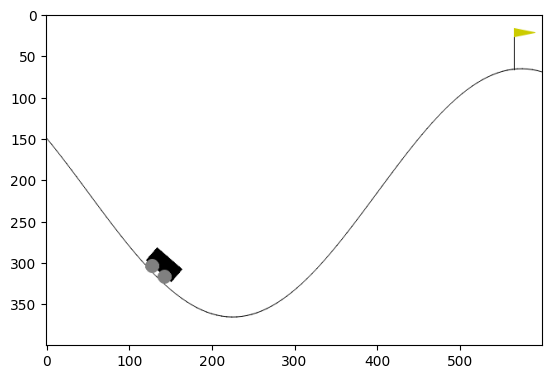

Finished watching the trained agent play!


In [ ]:
'''
Extra, i wanted to visualize the agent actually playing instead of just watching logs, similar to the Frozen Lake demonstration.
DEMONSTRATION: Watching the trained agent play

instead of changing visualize_env to True to watch the training instead of the logs,
created a new cell to watch the trained agent play a few episodes 
'''

# reset the environment to watch the trained agent play a few episodes
state, info = env.reset()
state = torch.Tensor(state).unsqueeze(0)
done = False # controls the episode loop and becomes true when the eipose ends

while not done:
    q_values = model(state) # get the Q values for the current state from the trained model
    action = torch.argmax(q_values).item() # get the action with the highest Q value
    
    # Take the action in the environmen
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated  # Episode ends on either condition
    next_state = torch.Tensor(next_state).unsqueeze(0)

    # display the environment to watch the trained agent play
    display_env(env)
    
print("Finished watching the trained agent play!")
    

#### Visualize your Training Process
In the code block below, use your prefered Python graphing library to create a graph showing how your total reward changed as you completed more episodes. Feel free to import any additional librarys you deem relevant.


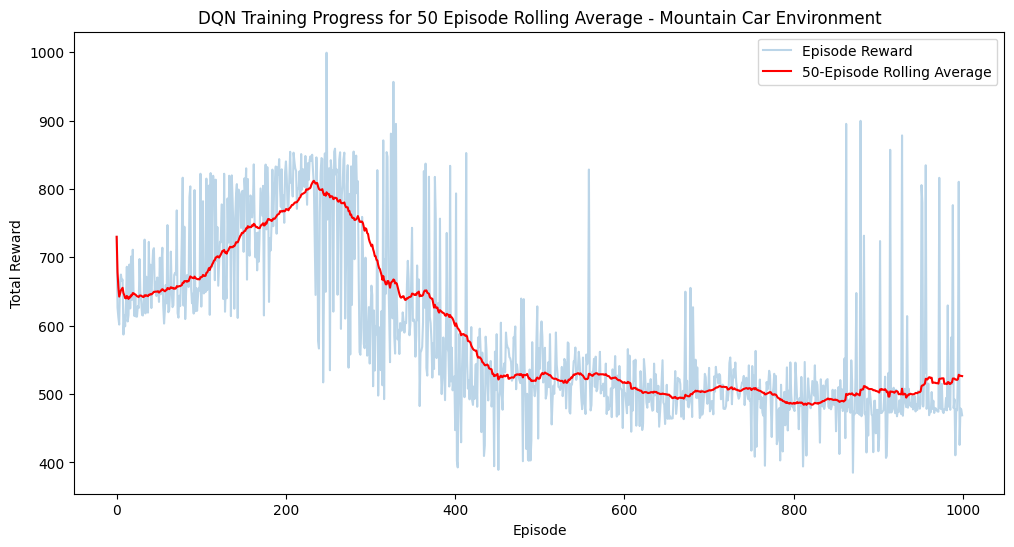

In [37]:
#### CREATE GRAPH USING PYTHON ####
    
# get figure size 
plt.figure(figsize=(12,6))
plt.plot(total_reward_by_episode, alpha=0.3, label='Episode Reward')

# Rolling average using pandas for easier calculation 
window = 50 
rolling_avg = pd.Series(total_reward_by_episode).rolling(window=window, min_periods=1).mean()

plt.plot(rolling_avg, label=f'{window}-Episode Rolling Average', color='red')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('DQN Training Progress for 50 Episode Rolling Average - Mountain Car Environment')
plt.legend()
plt.show()

# Reflect on your Training Process
In the markdown block below, describe in your own words how the training process went. Include information not only about how well your model was able to learn the tasks but also discuss how quickly it was able to learn, how long the training took, and any trends you notice in your `total_reward_by_episode` graph. Are there any potential improvements you think would make the training process go smoother or acheive a better result?


#### ENTER YOUR ANSWER HERE ####




## Reflection 

### Training Performance 
The model trained on 1000 episodes as shown in the train_dqn function, taking approximately 1 minute and 57 seconds to complete. I add a secondary verification if statement to check if the agent reaches the flag(terminated) or not (truncated). Upon running the demo numerous times, I never actually seen the car get up the hill or even attempt the hill with the flag at all. However, the algorithm does terminate, suggesting that the car is building momentum and attempted to swing toward reach the flag but never climbed the final hill to do so. Seems as if the reward shaping played an aggressive approach in accumulating positive rewards from position and velocity, leaving it satisfied enough to not attempt to reach the goal. Overall, the agent effectively learned to maximize collecting its rewards over solving the actual environment. 

### Graph Trends 
Upon review of the DQN reward graph there are 3 distinct phases. During episode 0 to around 370, the rolling average hovered around 600 to 850. During this phase it suggests the model is still exploring and actively discovering how momentum could push for higher velocity and positions. With higher positioning and velocity shows that the reward shaping is in full effect. In the 370 – 500 episodes range you can see the rolling average starts to taper off around the 500s range. This decline suggests that epsilon decay is playing its roll and shifting from an exploration to exploitation phase. The policy its learning off is slowly consolidating leading to mid-low optimization. In the remaining episodes 500 – 1000, rewards have become stabilize with a few outlier spikes reaching as high as 900. The policy has stabilized and found a consistent range to converge.

### Reason for adding Reward Shaping
The reason for adding the reward shaping was to help produce positive rewards over negative rewards already defaulted by the Mountain Car environment. Its core setup is to a -1 per step, which provides no positive signal to guide the agent to the goal. Without shaping, the agent is randomly exploring until it stumbles upon the momentum strategy to reach the goal. This can lead to increase compute times and take longer to converge. With expected values of -200 to -100, reward shaping inflates the total rewards bonus to positive, indicating that the algorithm is progressing toward higher highs for positions and velocity. As mentioned in the training performance, we can now clearly see the trade-off of implementing reward shaping versus without. Reward bonuses are being prioritized by the agent over actually navigating to the goal. 

### Training Speed 
Early in the training phase, around the first 100-200 episodes, the agent showed meaningful strides in learning at a strong pace. As a result, higher rewards and gradient signals were achieved. However, reward shaping seems to carry majority of the influence to training speed and not solely rely on sparse reward default. However, due to epsilon decay agent has transitioned from an exploration state to exploitation state. With this change in learning, it dramatically slowed the rate of improvement and committed to it learn policy instead of exploring newer strategies.

### Potential Improvements 

-	The biggest improvement I see is adjusting the reward shaping to not be so aggressive with the 50 points scaling. I think this will help with model being more consistent overall in learning through the entire 1000 episodes. Instead of starting strong and dramatically dropping off before halfway. Although there were some outliers that retested later in the training, it reveals that it some potential to have a better balance.
-	Fewer episodes could also help us get to the point. With adjustments from the reward shaping and cutting the episode down by half (500), convergence could be reached faster but also it should allow the model to reach the goal more times than often
-	To overcome the top two improvements a more conservative approach could be shifting to a Double DQN approach. We can see how the single DQN is overestimating very early and could be due to extra noise found. Double DQN, which utilize two networks, where the main network would select the best action, while the target network evaluates them, which could help to reduce the overestimating so early in the episode. Standard DQN will run this two-part job solely in the target network to get the best action and evaluate. Although the current implementation uses two networks, double DQN provides more flexibility and prevents the same network from making both decisions.
-	Implementing experience replay, where the algorithm is not relearning and replaying experiences but rather reviewing previously learned. This could help with memory and increase the agent’s ability to learn and have more success within episodes by sampling more frequently within the replay buffer.
-	A comparison to see how the agent trained the data with or without the reward shaping. True results versus inflated. Could negative rewards show a different perspective and consistent training than enabling reward shaping?

### Comparison to Frozen Lake 

A clear difference between Frozen Lake and Mountain car is size, static versus continuous state space. The Q-tables are dramatically different because one is finite while the other is infinite in possible position and velocity combinations stored to the table. Another clear difference is that DQN uses a neural network function to approximate and generalize across state space, this ability allows it to predict Q-values on unseen data. Scalability is important within the Mountain Car continuous state space because it would be nearly impossible and compute heavy to attempt to store every possible position/velocity Q-value combination on data that’s not even recognized yet.

While Frozen Lake utilized 16 discrete states in a basic 16x4 table, DQN’s ability to find and learn off unseen patterns provides an advantage allowing scalability and interpretability.  

